# Telco Customer Churn — Exploratory Data Analysis

**Author:** Allison Schiltz

> Dataset reference: *Telco Customer Churn* (Kaggle).
https://www.kaggle.com/datasets/blastchar/telco-customer-churn/code


**Inputs**
- Cleaned dataset from `data/processed/`
- Column-role manifest from data-wrangling handoff (ID, target, numeric, categorical, booleans)

**Primary goals**
- Understand target distribution and key drivers
- Identify relationships and interactions
- Inform feature engineering and modeling choices


## 0. Environment & Imports

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
import math

# Warning management
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Display options for better output
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
plt.style.use('default')
%matplotlib inline

print("Environment | pandas", pd.__version__, "| numpy", np.__version__)

Environment | pandas 2.3.3 | numpy 2.3.4


In [3]:
# Figure saving utilities
from pathlib import Path
FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name: str, dpi: int = 300):
    """Save current matplotlib figure to reports/figures with tight bbox."""
    out_path = FIG_DIR / name
    plt.savefig(out_path, dpi=dpi, bbox_inches='tight')
    print(f"Saved: {out_path.resolve()}")


## 1. Load Clean Data & Manifests
- Load cleaned dataset
- Load column-role manifest
- Basic integrity checks


In [4]:
# Load cleaned dataset
telco_clean = pd.read_csv('../data/processed/telco_wrangling_cleaned.csv')

# Load column-role manifest  
column_roles = pd.read_csv('../references/telco_column_role_manifest.csv')

# Basic integrity checks
print("Shape:", telco_clean.shape)
print("Info:")
telco_clean.info()
print("\nHead:")
print(telco_clean.head())
print("\nColumn roles:")
print(column_roles)

Shape: (7032, 27)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   customerID                       7032 non-null   object 
 1   gender                           7032 non-null   object 
 2   SeniorCitizen                    7032 non-null   object 
 3   Partner                          7032 non-null   object 
 4   Dependents                       7032 non-null   object 
 5   tenure                           7032 non-null   int64  
 6   PhoneService                     7032 non-null   object 
 7   MultipleLines                    7032 non-null   object 
 8   InternetService                  7032 non-null   object 
 9   OnlineSecurity                   7032 non-null   object 
 10  OnlineBackup                     7032 non-null   object 
 11  DeviceProtection                 7032 non-null   object 
 

In [5]:
# Convert categorical, boolean, and target columns to proper dtypes
categorical_columns = column_roles[column_roles['role'].isin(['categorical', 'boolean', 'target'])]['column_name']

# Loop through columns and set categorical dtypes
for col in categorical_columns:
    telco_clean[col] = telco_clean[col].astype('category')

# Convert engineered boolean to categorical for consistency
telco_clean['short_tenure_month_to_month_eng'] = np.where(
(telco_clean['tenure'] <= 12) & (telco_clean['Contract'] == 'Month-to-month'),
'Yes', 'No'
)
telco_clean['short_tenure_month_to_month_eng'] = telco_clean['short_tenure_month_to_month_eng'].astype('category')

# Ensure tenure_group_eng ordered chronologically
if 'tenure_group_eng' in telco_clean.columns:
    ordered_bins = ["0-6", "7-12", "13-24", "25-48", "49+"]
    telco_clean['tenure_group_eng'] = telco_clean['tenure_group_eng'].astype(str)
    telco_clean['tenure_group_eng'] = pd.Categorical(telco_clean['tenure_group_eng'], categories=ordered_bins, ordered=True)

print("\nUpdated data types:")
# Sort by data type name (convert to string first to avoid comparison issues)
print(telco_clean.dtypes.astype(str).sort_values())



Updated data types:
StreamingTV                        category
is_month_to_month_eng              category
monthly_charges_bin_eng            category
tenure_group_eng                   category
Churn                              category
PaymentMethod                      category
PaperlessBilling                   category
Contract                           category
StreamingMovies                    category
short_tenure_month_to_month_eng    category
TechSupport                        category
has_streaming_eng                  category
OnlineBackup                       category
OnlineSecurity                     category
InternetService                    category
MultipleLines                      category
PhoneService                       category
Dependents                         category
Partner                            category
SeniorCitizen                      category
gender                             category
DeviceProtection                   category
MonthlyChar

## 2. Target Variable Audit (`Churn`)
- Class balance (counts, percentages)


Churn counts: Churn
No     5163
Yes    1869
Name: count, dtype: int64 

Churn proportion: Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64 

Churn missing values: 0
Saved: /Users/Allison/Code/springboard_ds/springboard_projects/Capstone_2/reports/figures/eda_churn_distribution_pct.png


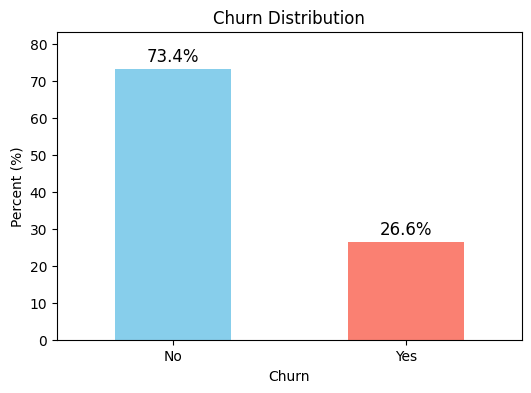

In [6]:
churn_counts = telco_clean['Churn'].value_counts()
print("Churn counts:", churn_counts, "\n")

churn_proportion = telco_clean['Churn'].value_counts(normalize=True) * 100
print("Churn proportion:", churn_proportion, "\n")

print("Churn missing values:", telco_clean['Churn'].isnull().sum())

plt.figure(figsize=(6, 4))
churn_proportion.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Percent (%)')
plt.xticks(rotation=0)

# Add headroom (e.g., +5%)
plt.ylim(0, churn_proportion.max() + 10)

for i, v in enumerate(churn_proportion):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontsize=12)
savefig('eda_churn_distribution_pct.png')
plt.show()



## 3. Univariate Exploration
### 3.1 Numeric

In [7]:
# Identify numeric columns
count_roles = column_roles['role'].value_counts()
print(count_roles, '\n')
numeric_cols = column_roles[column_roles['role'] == 'numeric']['column_name']
print('Numeric columns:\n', numeric_cols)

role
categorical    21
numeric         4
target          1
id              1
Name: count, dtype: int64 

Numeric columns:
 2                 tenure
3         MonthlyCharges
4           TotalCharges
22    total_services_eng
Name: column_name, dtype: object


In [8]:
# Identify all non-numeric columns by dtype (excluding target)
all_non_numeric = telco_clean.select_dtypes(include=['category']).columns
all_non_numeric = all_non_numeric[all_non_numeric != 'Churn']  # Exclude target variable
print(f'All non-numeric predictor columns ({len(all_non_numeric)} total):')
print(all_non_numeric.tolist())
for col_name in all_non_numeric:
    print(f"\nvalue counts:")
    print(telco_clean[col_name].value_counts(), '\n')
    print(f"proportion:")
    print(telco_clean[col_name].value_counts(normalize=True), '\n')

# Flag rare categories (< 5% of data) if any
for col_name in all_non_numeric:
    rare_threshold = len(telco_clean) * 0.05
    rare_cats = telco_clean[col_name].value_counts() < rare_threshold
    if rare_cats.any():
        print(f'{col_name} rare categories:')
        print('\n', rare_cats[rare_cats].index.tolist())


All non-numeric predictor columns (21 total):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group_eng', 'monthly_charges_bin_eng', 'is_month_to_month_eng', 'short_tenure_month_to_month_eng', 'has_streaming_eng']

value counts:
gender
Male      3549
Female    3483
Name: count, dtype: int64 

proportion:
gender
Male      0.504693
Female    0.495307
Name: proportion, dtype: float64 


value counts:
SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64 

proportion:
SeniorCitizen
No     0.8376
Yes    0.1624
Name: proportion, dtype: float64 


value counts:
Partner
No     3639
Yes    3393
Name: count, dtype: int64 

proportion:
Partner
No     0.517491
Yes    0.482509
Name: proportion, dtype: float64 


value counts:
Dependents
No     4933
Yes    2099
Name: count, dt

## 4. Bivariate Analysis vs Target
### 4.1 Numeric vs `Churn`


Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'total_services_eng']


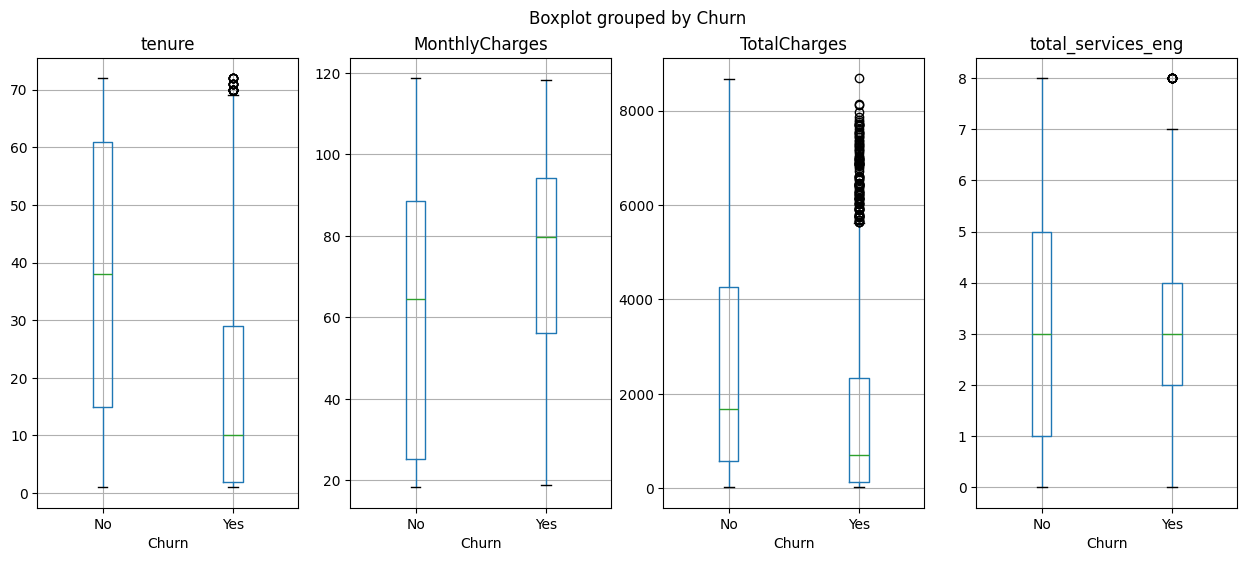

In [9]:
print('Numeric columns:', numeric_cols.tolist())

# Compare distributions by churn status
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 6))
for i, col in enumerate(numeric_cols):
    # Box plot by churn
    telco_clean.boxplot(column=col, by='Churn', ax=axes[i])

Saved: /Users/Allison/Code/springboard_ds/springboard_projects/Capstone_2/reports/figures/eda_tenure_by_churn_boxplot.png


<Figure size 600x400 with 0 Axes>

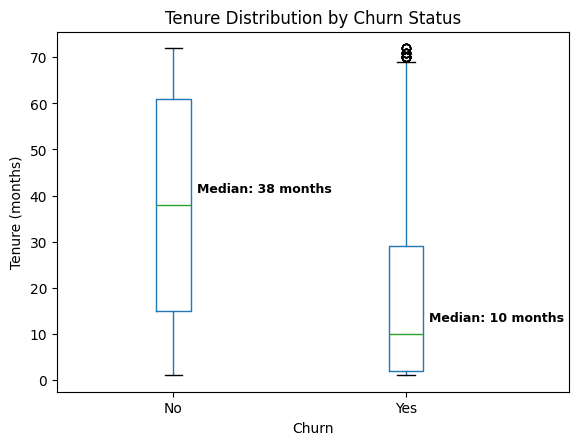

In [10]:
# Dedicated box plot for tenure by churn status
plt.figure(figsize=(6, 4))
ax = telco_clean.boxplot(column='tenure', by='Churn', grid=False)
plt.title('Tenure Distribution by Churn Status')
plt.suptitle('')  # Remove automatic suptitle
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')

# Calculate and label medians
medians = telco_clean.groupby('Churn')['tenure'].median()
for i, (label, median) in enumerate(medians.items()):
    plt.text(i + 1.1, median + 2, f"Median: {median:.0f} months",
             ha='left', va='bottom', fontsize=9, color='black', fontweight='bold')

# Add x-axis limits to allow space for median labels
plt.xlim(0.5, 2.7)

savefig('eda_tenure_by_churn_boxplot.png')
plt.show()


**Numeric shape:** Tenure is right-skewed with a heavy early-customer concentration (new users churn more), MonthlyCharges is moderately right-skewed (long tail of higher bills), and TotalCharges is very right-skewed due to the cumulative effect of tenure.

In [11]:
# Group statistics
for col in numeric_cols:
    print(f"\n{col}:")
    stats = telco_clean.groupby('Churn')[col].agg(['mean', 'median', 'std'])
    print(stats)


tenure:
            mean  median        std
Churn                              
No     37.650010    38.0  24.076940
Yes    17.979133    10.0  19.531123

MonthlyCharges:
            mean  median        std
Churn                              
No     61.307408   64.45  31.094557
Yes    74.441332   79.65  24.666053

TotalCharges:
              mean   median          std
Churn                                   
No     2555.344141  1683.60  2329.456984
Yes    1531.796094   703.55  1890.822994

total_services_eng:
           mean  median       std
Churn                            
No     3.447027     3.0  2.156609
Yes    3.132156     3.0  1.754828


In [12]:
# Cohen's d for effect size
# 0.2 = small effect
# 0.5 = medium effect  
# 0.8 = large effect

import pingouin as pg

# Store Cohen's d results for summary table
cohens_d_results = []

for col in numeric_cols:
    churn_yes = telco_clean[telco_clean['Churn'] == 'Yes'][col]
    churn_no = telco_clean[telco_clean['Churn'] == 'No'][col]
    
    # Calculate Cohen's d using Pingouin
    d = pg.compute_effsize(churn_yes, churn_no, eftype='cohen')
    
    # Interpret effect size
    abs_d = abs(d)
    if abs_d < 0.2:
        effect = "negligible"
    elif abs_d < 0.5:
        effect = "small"
    elif abs_d < 0.8:
        effect = "medium"
    else:
        effect = "large"
    
    # Store results for summary table
    cohens_d_results.append({
        'Variable': col,
        'Type': 'Numeric',
        'Effect_Size': abs_d,  # Use absolute value for ranking
        'Raw_Effect_Size': d,  # Keep original for reference
        'Effect_Magnitude': effect
    })
    
    print(f"{col}: Cohen's d = {d:.3f} ({effect})")

tenure: Cohen's d = -0.857 (large)
MonthlyCharges: Cohen's d = 0.445 (small)
TotalCharges: Cohen's d = -0.461 (small)
total_services_eng: Cohen's d = -0.153 (negligible)



### 4.2 Categorical vs `Churn`
- Grouped churn rates
- Association measures

In [13]:
# Calculate overall churn rate
overall_churn_rate = telco_clean['Churn'].value_counts(normalize=True)['Yes']

# Calculate churn rates by category for each categorical variable
for col in all_non_numeric:
    print(f"\n{col} - Churn Rates:")
    churn_rates = telco_clean.groupby(col)['Churn'].value_counts(normalize=True).unstack()
    print(churn_rates)


rows = []
for col in all_non_numeric:
    rates = (
        telco_clean.groupby(col)['Churn']
        .apply(lambda s: (s == 'Yes').mean())
        .astype(float)  # ensure numeric
        .rename('churn_rate')
    )
    counts = telco_clean[col].value_counts().rename('count')
    df = pd.concat([rates, counts], axis=1).reset_index().rename(columns={col: 'category'})
    df.insert(0, 'feature', col)
    # Ensure churn_rate is numeric before computing lift
    df['churn_rate'] = pd.to_numeric(df['churn_rate'], errors='coerce')
    df['lift'] = df['churn_rate'] - float(overall_churn_rate)
    rows.append(df[df['churn_rate'] > overall_churn_rate])

above_avg = (
    pd.concat(rows, ignore_index=True)
      .sort_values(['lift','count'], ascending=[False, False])
      .reset_index(drop=True)
)

# Pretty formatting
out = above_avg.copy()
out['churn_rate'] = (out['churn_rate'] * 100).round(1).astype(str) + '%'
out['lift'] = (above_avg['lift'] * 100).round(1).map(lambda x: f"+{x}%" if x >= 0 else f"{x}%")
out = out[['feature','category','churn_rate','count']]

print(f"Overall churn rate: {overall_churn_rate:.1%}\n")
display(out.head(30))  # show top 30


gender - Churn Rates:
Churn         No       Yes
gender                    
Female  0.730405  0.269595
Male    0.737954  0.262046

SeniorCitizen - Churn Rates:
Churn                No       Yes
SeniorCitizen                    
No             0.763497  0.236503
Yes            0.583187  0.416813

Partner - Churn Rates:
Churn          No       Yes
Partner                    
No       0.670239  0.329761
Yes      0.802829  0.197171

Dependents - Churn Rates:
Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.844688  0.155312

PhoneService - Churn Rates:
Churn               No       Yes
PhoneService                    
No            0.750000  0.250000
Yes           0.732525  0.267475

MultipleLines - Churn Rates:
Churn                   No       Yes
MultipleLines                       
No                0.749188  0.250812
No phone service  0.750000  0.250000
Yes               0.713515  0.286485

InternetService - Churn Rates:
Churn   

,feature,category,churn_rate,count
0,tenure_group_eng,0-6,53.3%,1470
1,short_tenure_month_to_month_eng,Yes,51.4%,1994
2,PaymentMethod,Electronic check,45.3%,2365
3,Contract,Month-to-month,42.7%,3875
4,is_month_to_month_eng,Yes,42.7%,3875
5,InternetService,Fiber optic,41.9%,3096
6,OnlineSecurity,No,41.8%,3497
7,SeniorCitizen,Yes,41.7%,1142
8,TechSupport,No,41.6%,3472
9,OnlineBackup,No,39.9%,3087



The association between categorical features and target (Churn) using Cramér's V:


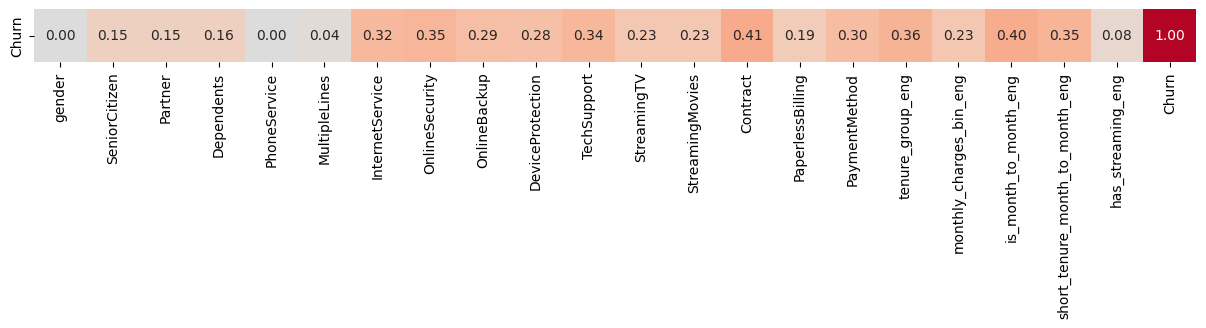

In [14]:
# Import dython associations module
from dython.nominal import associations

print('\nThe association between categorical features and target (Churn) using Cramér\'s V:')


# Create association matrix
association_dictionary = associations(telco_clean[list(all_non_numeric) + ['Churn']], 
                                      nominal_columns = list(all_non_numeric) + ['Churn'], 
                                      display_rows = ['Churn'], 
                                      nan_strategy = 'drop_samples',
                                      figsize= (15, 15), 
                                      compute_only = False, 
                                      cbar = False,
                                      cmap = 'coolwarm')

In [15]:
target_vs_cat = association_dictionary['corr'].stack().sort_values(ascending = False)
print('Table of associations between categorical features and target (Churn)\nusing Cramér\'s V:\n')
print(target_vs_cat)

Table of associations between categorical features and target (Churn)
using Cramér's V:

Churn  Churn                              1.000000
       Contract                           0.409242
       is_month_to_month_eng              0.404094
       tenure_group_eng                   0.364539
       short_tenure_month_to_month_eng    0.352308
       OnlineSecurity                     0.346607
       TechSupport                        0.342115
       InternetService                    0.321490
       PaymentMethod                      0.302276
       OnlineBackup                       0.291435
       DeviceProtection                   0.280672
       StreamingMovies                    0.230101
       StreamingTV                        0.229541
       monthly_charges_bin_eng            0.229081
       PaperlessBilling                   0.190768
       Dependents                         0.162351
       SeniorCitizen                      0.149641
       Partner                            0.

#### Interpretation of Cramér’s V

The correlations between the target (Churn) and Categorical variables in this dataset are "negligible" to "relatively strong", but the "relatively strong" values are very close to the cutoff between "relatively strong" and moderate. For reference, see table below.

**General Interpreation Table:**

| Cramér's V | Strength of Association | Typical Interpretation |
|------------|------------------------|------------------------|
| 0.00 – 0.10 | Very weak / negligible | Variables are essentially independent |
| 0.10 – 0.20 | Weak | Small relationship present |
| 0.20 – 0.40 | Moderate | Noticeable relationship |
| 0.40 – 0.60 | Relatively strong | Clear relationship between categories |
| 0.60 – 0.80 | Strong | Substantial association |
| 0.80 – 1.00 | Very strong / perfect | Almost deterministic relationship |


In [16]:
# Bivariate summary with separate tables for numeric and categorical
print("\n" + "="*60)
print("BIVARIATE SUMMARY: CHURN PREDICTORS BY TYPE")
print("="*60)

# Separate numeric and categorical results
numeric_summary = pd.DataFrame(cohens_d_results).sort_values('Effect_Size', ascending=False)
numeric_summary = numeric_summary.drop(columns=['Raw_Effect_Size', 'Type'])
categorical_summary = target_vs_cat.reset_index()
categorical_summary = categorical_summary.drop(columns=['level_0'])
categorical_summary = categorical_summary.drop(index=0)  # Drop self-correlation row
categorical_summary.columns = ['Variable', 'Effect_Size']


# Add effect magnitude interpretation for categorical variables (Cramér's V)
def interpret_cramers_v(value):
    if value < 0.10:
        return "negligible"
    elif value < 0.20:
        return "weak"
    elif value < 0.40:
        return "moderate"
    elif value < 0.60:
        return "relatively strong"
    else:
        return "very strong"

categorical_summary['Effect_Magnitude'] = categorical_summary['Effect_Size'].apply(interpret_cramers_v)
categorical_summary = categorical_summary.sort_values('Effect_Size', ascending=False)

# NUMERIC PREDICTORS TABLE
print("\n NUMERIC PREDICTORS (Cohen's d)")
print("-" * 80)
print(numeric_summary, '\n')

# CATEGORICAL PREDICTORS TABLE  
print(f"\n CATEGORICAL PREDICTORS (Cramér's V)")
print("-" * 80)
print(categorical_summary)

# See markdown cell below for key insights summary


BIVARIATE SUMMARY: CHURN PREDICTORS BY TYPE

 NUMERIC PREDICTORS (Cohen's d)
--------------------------------------------------------------------------------
             Variable  Effect_Size Effect_Magnitude
0              tenure     0.856857            large
2        TotalCharges     0.460773            small
1      MonthlyCharges     0.444867            small
3  total_services_eng     0.153034       negligible 


 CATEGORICAL PREDICTORS (Cramér's V)
--------------------------------------------------------------------------------
                           Variable  Effect_Size   Effect_Magnitude
1                          Contract     0.409242  relatively strong
2             is_month_to_month_eng     0.404094  relatively strong
3                  tenure_group_eng     0.364539           moderate
4   short_tenure_month_to_month_eng     0.352308           moderate
5                    OnlineSecurity     0.346607           moderate
6                       TechSupport     0.342115    

#### The code below shows customer churn by categorical features chosen for their strong association with churn (highest Cramér’s V values), while including only one tenure-related variable to avoid redundancy.

- **'Contract'** and **'tenure_group_eng'** capture key aspects of the customer lifecycle and contract risk.  
- **`InternetService`** indicates whether customers have internet service and is necessary for the add-ons.
-  **`OnlineSecurity`**, and **'TechSupport'** are the most impactful add-on services.  
- **`monthly_charges_bin_eng`** serves as a proxy for overall billing level or bundle cost.  
- **`PaymentMethod`** reflects how customers pay and whether auto-pay is set up.  

This selection highlights distinct patterns and behaviors, ensuring each variable adds unique information rather than duplicating what is already captured by others.








Saved: /Users/Allison/Code/springboard_ds/springboard_projects/Capstone_2/reports/figures/eda_churn_rate_grid.png


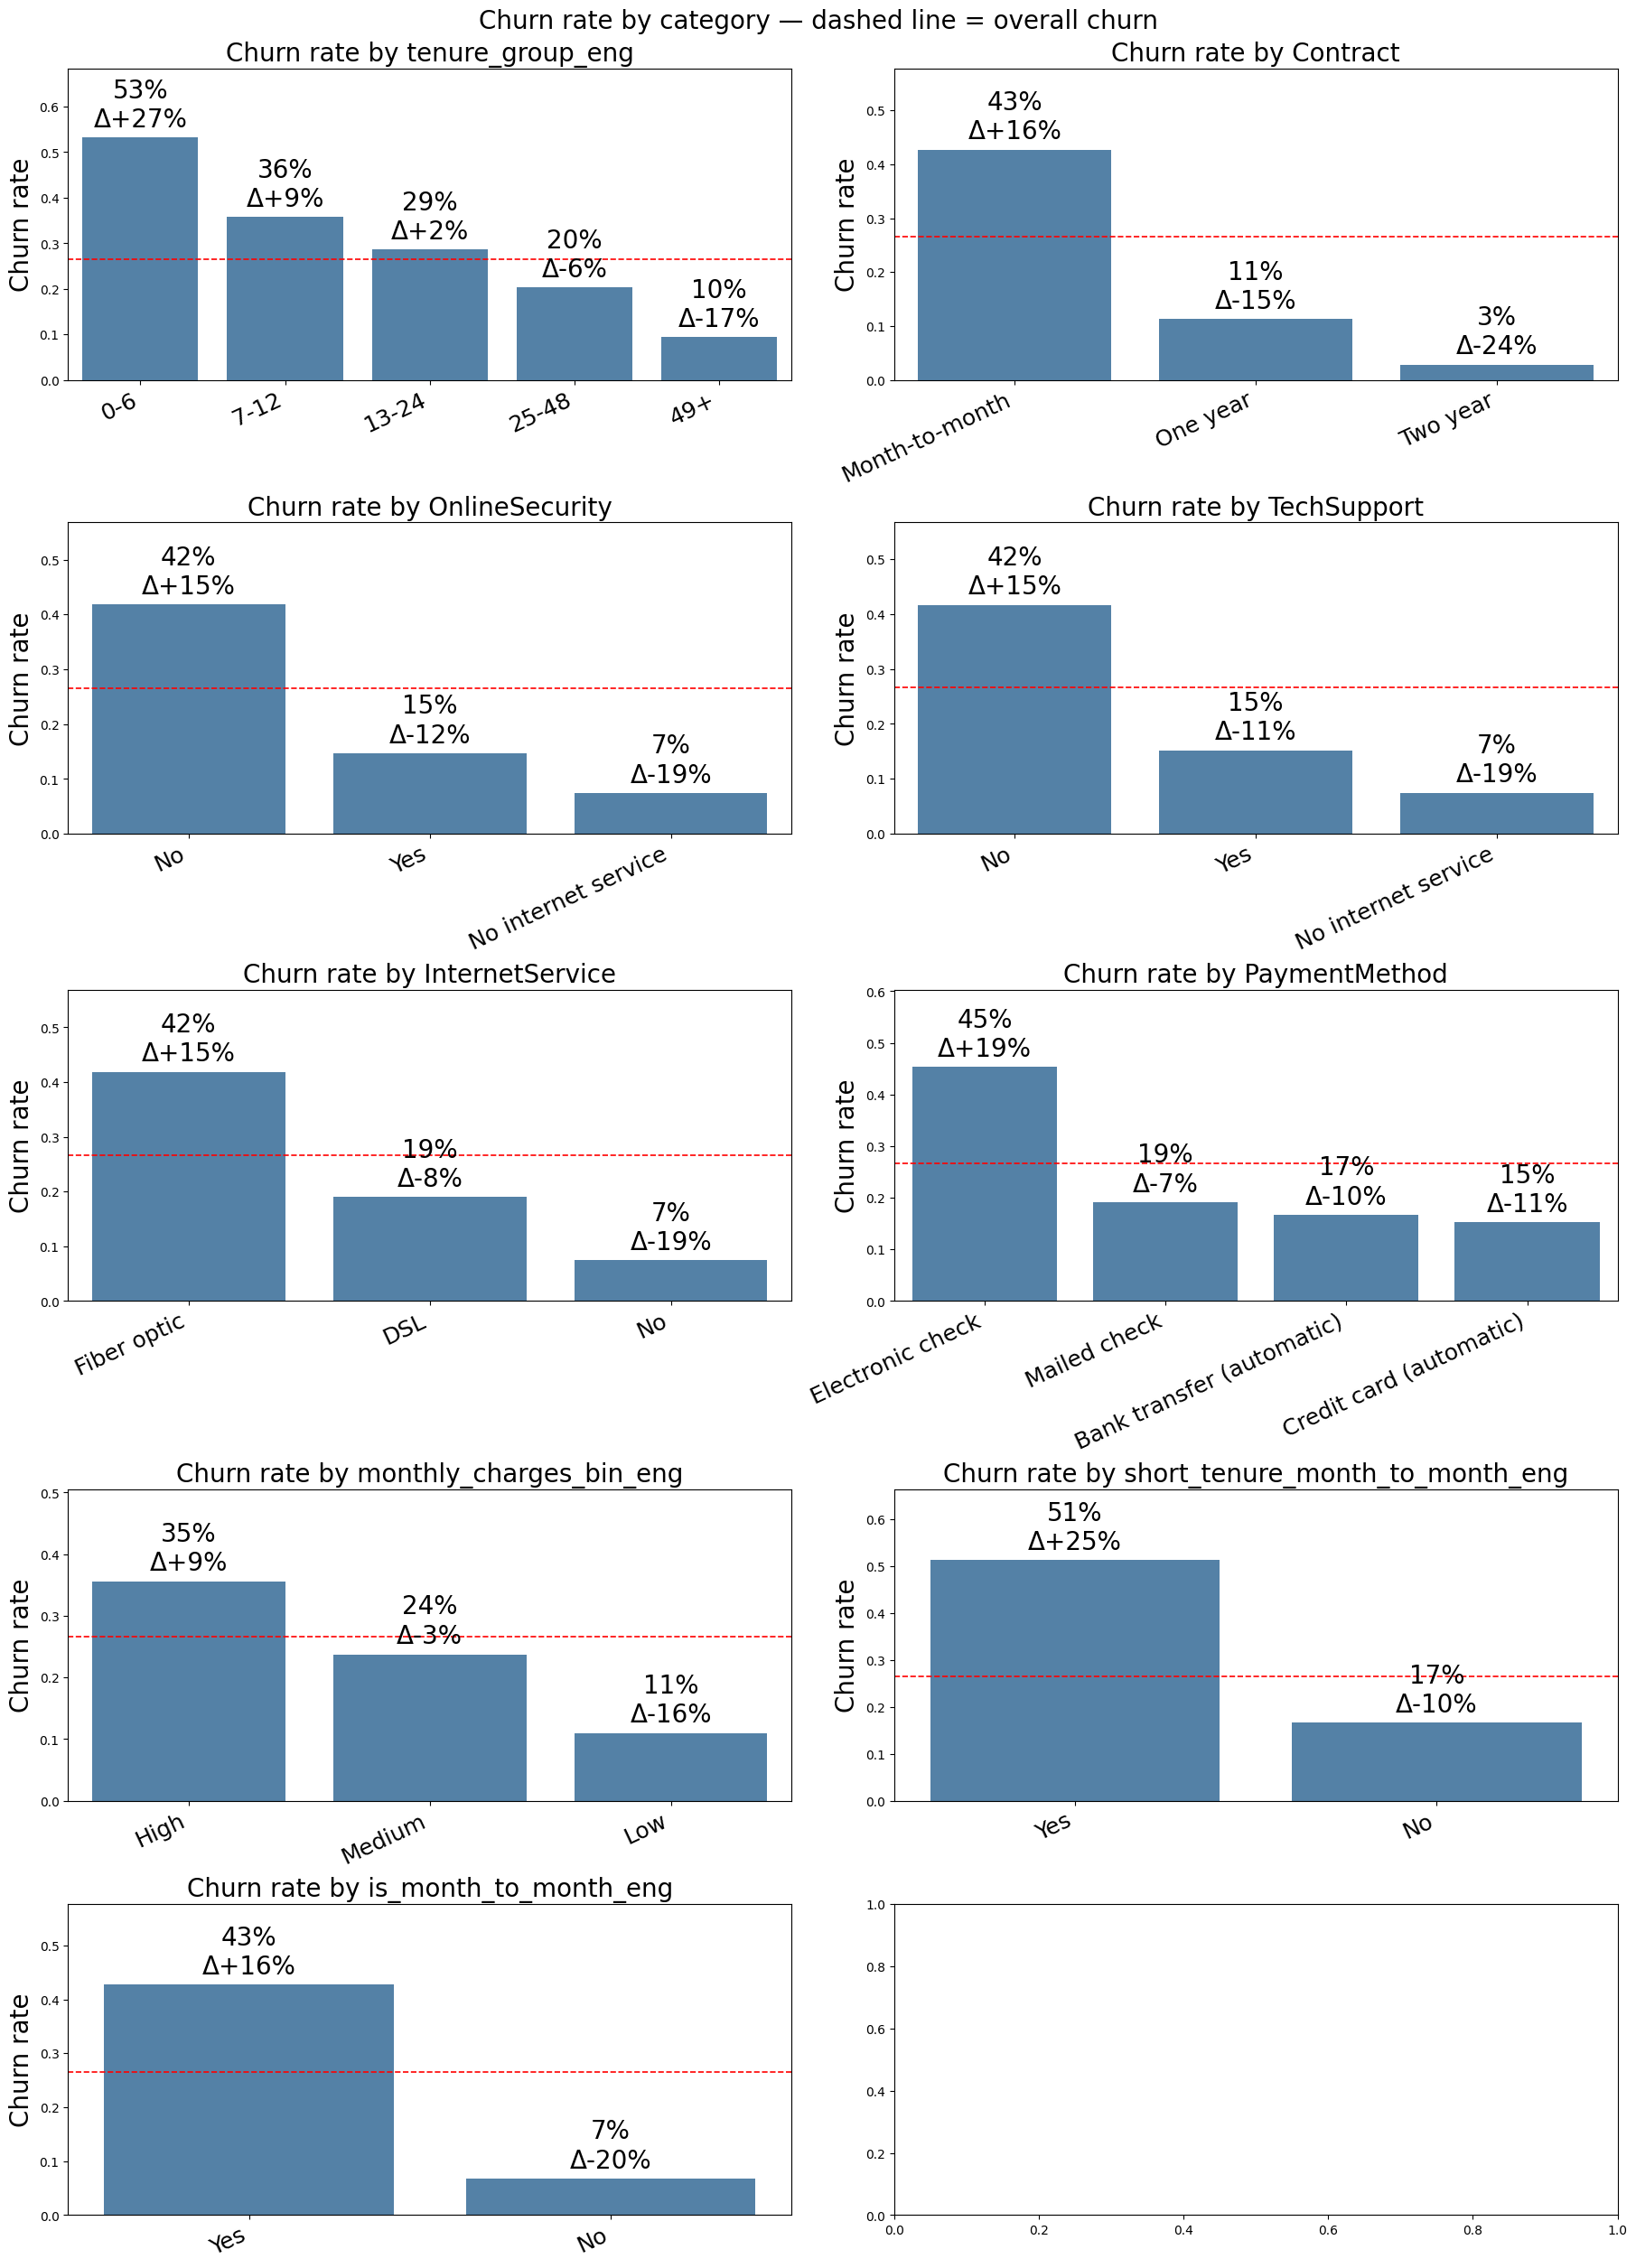

In [17]:
# Visualize category-level churn rates for representative categorical features
from IPython.display import display

def churn_rates_by(col: str) -> pd.DataFrame:
    """Return a DataFrame with churn_rate and count by category for col."""
    df = telco_clean[[col, 'Churn']].dropna()
    rates = df.groupby(col, observed=True)['Churn'].apply(lambda s: (s == 'Yes').mean()).rename('churn_rate')
    counts = df[col].value_counts().rename('count')
    out = pd.concat([rates, counts], axis=1)
    if hasattr(df[col].dtype, 'ordered') and df[col].dtype.ordered:
        out = out.reindex(df[col].cat.categories)
    else:
        out = out.sort_index()
    return out


def plot_churn_rate_bar(col: str, ax):
    out = churn_rates_by(col)
    if not (hasattr(telco_clean[col].dtype, 'ordered') and telco_clean[col].dtype.ordered):
        out = out.sort_values('churn_rate', ascending=False)

    sns.barplot(x=out.index.astype(str), y=out['churn_rate'], color='steelblue', ax=ax)
    ax.axhline(overall_churn_rate, color='red', linestyle='--', lw=1.2)
    ax.set_title(f"Churn rate by {col}", fontsize=20)
    ax.set_ylabel('Churn rate', fontsize=20)
    ax.set_xlabel('')  # Remove feature label from x-axis
    ax.set_ylim(0, min(1.0, out['churn_rate'].max() + 0.15))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=18)

    for i, (_, row) in enumerate(out.iterrows()):
        lift = row['churn_rate'] - overall_churn_rate
        ax.text(i, row['churn_rate'] + 0.01,
                f"{row['churn_rate']:.0%}\nΔ{lift:+.0%}",
                ha='center', va='bottom', fontsize=20)

features = ['tenure_group_eng','Contract', 'OnlineSecurity', 'TechSupport', 'InternetService', 'PaymentMethod', 'monthly_charges_bin_eng', 'short_tenure_month_to_month_eng', 'is_month_to_month_eng']
fig, axes = plt.subplots(5, 2, figsize=(18, 25), constrained_layout=True)
for ax, col in zip(axes.ravel(), features):
    plot_churn_rate_bar(col, ax=ax)
fig.suptitle('Churn rate by category — dashed line = overall churn', fontsize=20)
savefig('eda_churn_rate_grid.png')
plt.show()


Saved: /Users/Allison/Code/springboard_ds/springboard_projects/Capstone_2/reports/figures/eda_churn_rate_tenure_group.png


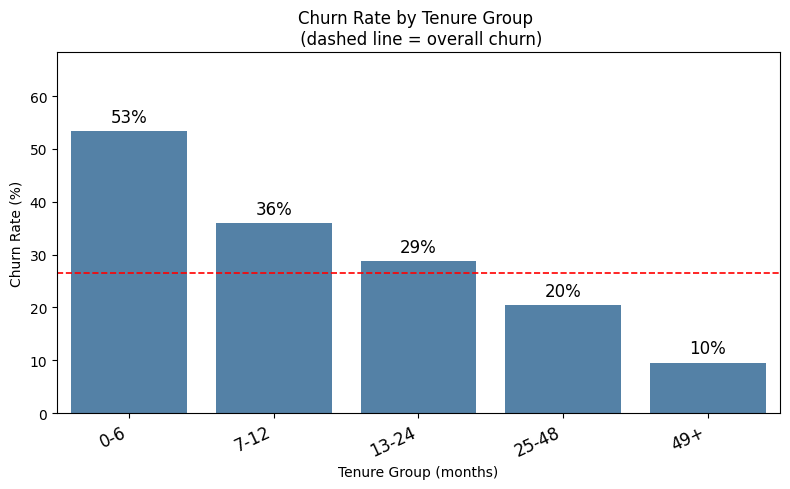

In [25]:
# Plot churn rate by tenure_group_eng only

# Calculate churn rate by tenure group
out = telco_clean[['tenure_group_eng', 'Churn']].dropna()
churn_rates = out.groupby('tenure_group_eng', observed=True)['Churn'].apply(lambda s: (s == 'Yes').mean()) * 100
counts = out['tenure_group_eng'].value_counts().reindex(churn_rates.index)
overall_churn_rate = telco_clean['Churn'].value_counts(normalize=True)['Yes'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_rates.index.astype(str), y=churn_rates.values, color='steelblue')
plt.axhline(overall_churn_rate, color='red', linestyle='--', lw=1.2)
plt.title('Churn Rate by Tenure Group \n (dashed line = overall churn)')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure Group (months)')
plt.ylim(0, min(100, churn_rates.max() + 15))
plt.xticks(rotation=25, ha='right', fontsize=12)

# Annotate bars with churn rate and lift
for i, (cat, rate) in enumerate(churn_rates.items()):
    plt.text(i, rate + 1, f"{rate:.0f}%", ha='center', va='bottom', fontsize=12)

plt.tight_layout()

savefig('eda_churn_rate_tenure_group.png')

plt.show()

Saved: /Users/Allison/Code/springboard_ds/springboard_projects/Capstone_2/reports/figures/eda_churn_rate_contract.png


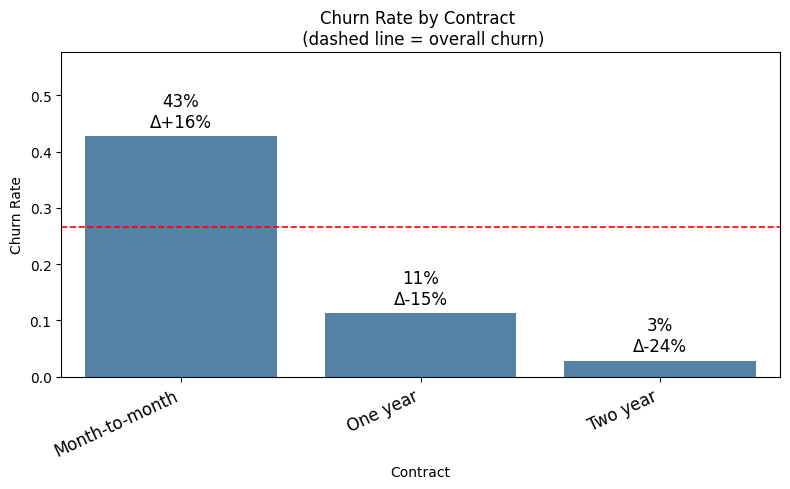

In [19]:
# Plot churn rate by Contract only

# Calculate churn rate by Contract
out = telco_clean[['Contract', 'Churn']].dropna()
churn_rates = out.groupby('Contract', observed=True)['Churn'].apply(lambda s: (s == 'Yes').mean())
counts = out['Contract'].value_counts().reindex(churn_rates.index)
overall_churn_rate = telco_clean['Churn'].value_counts(normalize=True)['Yes']

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_rates.index.astype(str), y=churn_rates.values, color='steelblue')
plt.axhline(overall_churn_rate, color='red', linestyle='--', lw=1.2)
plt.title('Churn Rate by Contract \n (dashed line = overall churn)')
plt.ylabel('Churn Rate')
plt.xlabel('Contract')
plt.ylim(0, min(1.0, churn_rates.max() + 0.15))
plt.xticks(rotation=25, ha='right', fontsize=12)

# Annotate bars with churn rate and lift
for i, (cat, rate) in enumerate(churn_rates.items()):
    lift = rate - overall_churn_rate
    plt.text(i, rate + 0.01, f"{rate:.0%}\nΔ{lift:+.0%}", ha='center', va='bottom', fontsize=12)

plt.tight_layout()

savefig('eda_churn_rate_contract.png')

plt.show()

#### KEY INSIGHTS:

> Note: Effect sizes between numeric and categorical predictors are not directly comparable due to different calculation methods.

- STRONGEST numeric predictor: `tenure` (large effect, Cohen's d = -0.857)
- STRONGEST categorical predictor: `Contract` (relatively large effect, Cramér's V = 0.410)
- Among numeric predictors, `tenure` shows the only 'large' effect size
- Most categorical predictors show weak to moderate effects
- Negligible predictors: `gender`, `PhoneService`, `MultipleLines`

- Key category-level churn segments

Top 5 categories by churn rate (vs overall baseline):

| Feature | Category | Churn rate | Lift vs baseline |
|---|---|---:|---:|
| tenure_group_eng | 0–6 | 53.3% | +26.8% |
| PaymentMethod | Electronic check | 45.3% | +18.7% |
| Contract | Month-to-month | 42.7% | +16.1% |
| InternetService | Fiber optic | 41.9% | +15.3% |
| TechSupport | No | 41.6% | +15.1% |

Lowest 5 categories by churn rate:

| Feature | Category | Churn rate | Lift vs baseline |
|---|---|---:|---:|
| monthly_charges_bin_eng | Low | 10.9% | -15.7% |
| tenure_group_eng | 49+ | 9.5% | -17.1% |
| InternetService | No | 7.4% | -19.1% |
| TechSupport | No internet service | 7.4% | -19.1% |
| Contract | Two year | 2.8% | -23.7% |

## 5. Multivariate Exploration


NUMERIC VARIABLE CORRELATIONS
Correlation Matrix:
                      tenure  MonthlyCharges  TotalCharges  total_services_eng
tenure              1.000000        0.246862      0.825880            0.524441
MonthlyCharges      0.246862        1.000000      0.651065            0.802368
TotalCharges        0.825880        0.651065      1.000000            0.796885
total_services_eng  0.524441        0.802368      0.796885            1.000000
Saved: /Users/Allison/Code/springboard_ds/springboard_projects/Capstone_2/reports/figures/eda_numeric_correlation_heatmap.png


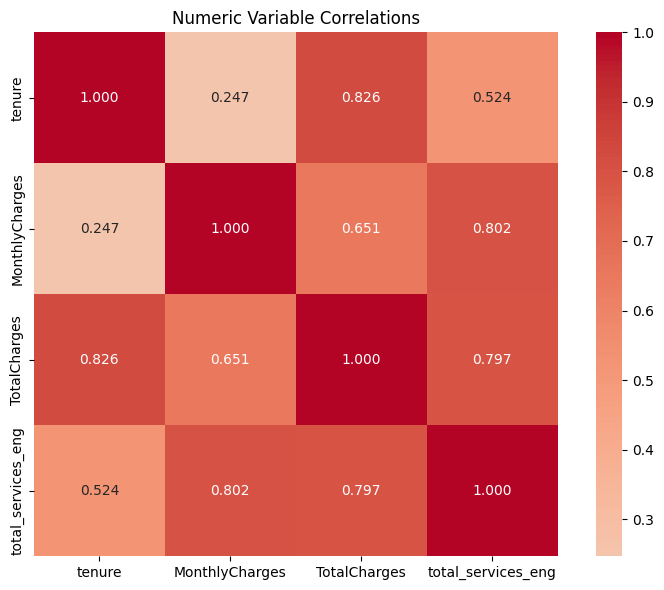

Saved: /Users/Allison/Code/springboard_ds/springboard_projects/Capstone_2/reports/figures/eda_contract_by_tenure_rownorm.png


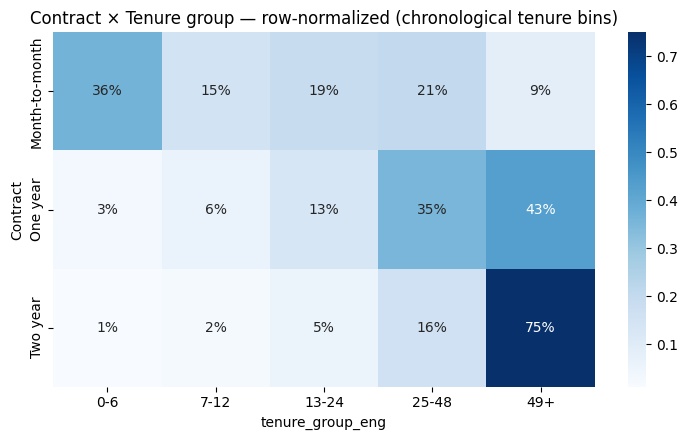

In [20]:
# 5.1 Numeric-Numeric correlations - check multicollinearity
print("NUMERIC VARIABLE CORRELATIONS")
print("="*40)

# Create correlation matrix for numeric variables
numeric_data = telco_clean[numeric_cols]
correlation_matrix = numeric_data.corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Visualize correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Numeric Variable Correlations')
savefig('eda_numeric_correlation_heatmap.png')
plt.tight_layout()
plt.show()

# Interaction heatmap: Contract × tenure_group_eng with enforced column order
ordered_bins = ["0-6", "7-12", "13-24", "25-48", "49+"]
ct = pd.crosstab(telco_clean['Contract'], telco_clean['tenure_group_eng'])
ct = ct.reindex(columns=ordered_bins)
ct_pct = ct.div(ct.sum(axis=1), axis=0)
plt.figure(figsize=(7.5, 4.5))
sns.heatmap(ct_pct, annot=True, fmt='.0%', cmap='Blues', cbar=True)
plt.title('Contract × Tenure group — row-normalized (chronological tenure bins)')
plt.xlabel('tenure_group_eng')
plt.ylabel('Contract')
savefig('eda_contract_by_tenure_rownorm.png')
plt.tight_layout()
plt.show()


### Interpretation of interactions between contract type and tenure group

- 36% of month-to-month customers are in the earliest tenure bin (0–6 months), highlighting a high-risk segment for churn among new, flexible-contract customers.
- One-year contract customers are more evenly distributed, with 35% in the 25–48 month bin and 43% in the 49+ month bin.
- 75% of two-year contract customers are in the 49+ month tenure group, indicating strong retention and stability among long-term contract holders.

This pattern underscores the importance of contract length and tenure in predicting churn risk.

#### High Correlations (>0.7)

- **tenure ↔ TotalCharges: 0.826**
  - customers with longer tenure have higher total charges
- **MonthlyCharges ↔ total_services_eng: 0.802**
  - more services = higher monthly bill
- **TotalCharges ↔ total_services_eng: 0.797**
  - more services over time = higher total

##### Notes for modeling:
- These variables measure similar things (**multicollinearity**)

- Consider dropping `TotalCharges` and `total_services_eng` since:
  - `TotalCharges` is derived from `MonthlyCharges` and `tenure` 
  - `total_services_eng` is a composite variable and the effect size is negligible


#### Contract × tenure_group_eng interaction:
- highlights concentration of short-tenure customers in month-to-month contracts driving early churn risk and strong retention and stability among long-term contract holders



CATEGORICAL PREDICTOR ASSOCIATIONS


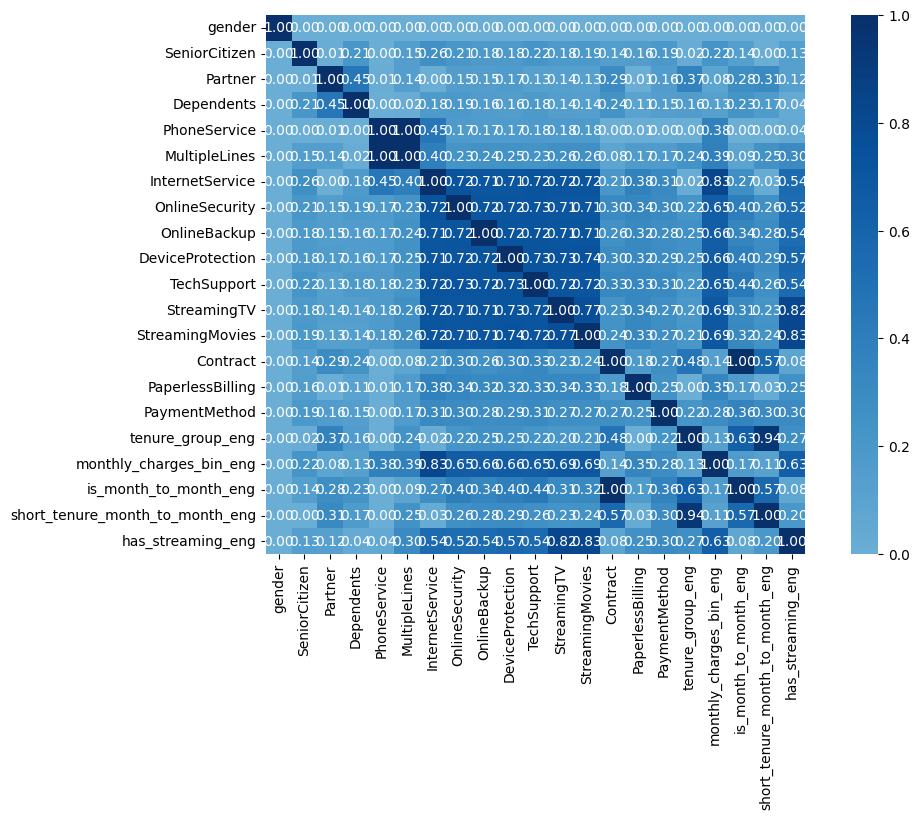

In [21]:
# 5.2 Categorical-Categorical collinearity - association matrix using dython
from dython.nominal import associations

print("\n" + "="*50)
print("CATEGORICAL PREDICTOR ASSOCIATIONS")  
print("="*50)


# Instantiate a figure and axis object
fig, ax = plt.subplots(figsize = (12, 7))
# Estimate and generate Cramer's V association plot
cramers_v = associations(telco_clean[all_non_numeric],
             nom_nom_assoc = 'cramer',
             ax = ax,
             cmap = "Blues")


In [22]:
# Round and store the Cramér's V matrix
cat_correlations = cramers_v["corr"].round(2)

# Show entries with correlation > 0.70
cat_correlations_high = cat_correlations[(cat_correlations > 0.70) & (cat_correlations < 1.00)]

# Remove rows and columns that are all NaN
cat_correlations_high = cat_correlations_high.dropna(axis=1, how='all').dropna(axis=0, how='all')

print(cat_correlations_high)

                                 InternetService  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
InternetService                              NaN            0.72          0.71              0.71         0.72         0.72   
OnlineSecurity                              0.72             NaN          0.72              0.72         0.73         0.71   
OnlineBackup                                0.71            0.72           NaN              0.72         0.72         0.71   
DeviceProtection                            0.71            0.72          0.72               NaN         0.73         0.73   
TechSupport                                 0.72            0.73          0.72              0.73          NaN         0.72   
StreamingTV                                 0.72            0.71          0.71              0.73         0.72          NaN   
StreamingMovies                             0.72            0.71          0.71              0.74         0.72         

### Summary of strongest Cramér’s V relationships (> 0.70)

- Internet service ↔ bundle (≈0.71–0.74)
  - InternetService is tightly linked to add-ons: OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies.
  - These add-ons require internet, so they move together.

- InternetService ↔ monthly_charges_bin_eng (0.83).
  - Higher monthly charges mostly reflect having internet and more add‑ons, making the binned charge a proxy for the service bundle.

- StreamingTV ↔ StreamingMovies (0.77).
  - Customers with one streaming service usually have the other, so these variables are redundant.

- Tenure_group_eng ↔ short_tenure_month_to_month_eng (0.94).
  -  short_tenure_month_to_month_eng flag is essentially a relabeling of the first-year bins (0–6 and 7–12 months) among month-to-month customers. Because most month-to-month customers are in their first year, this flag is highly overlapping with tenure_group_eng.
  - Variable definitions
    - short_tenure_month_to_month_eng: "Yes" if tenure ≤ 12 months AND Contract = "Month-to-month"; otherwise "No".
    - tenure_group_eng: tenure binned into "0–6", "7–12", "13–24", "25–48", "49+" months.

- is_month_to_month ↔ Contract (1.00)



In [23]:
# Calculate correlation between MonthlyCharges, InternetService, and Add-ons since monthly_charges_bin_eng and InternetService are highly correlated, and InternetService is highly correlated with all add-ons.
# pingouin computes eta squared (η²), so take the square root for eta

add_ons = ['InternetService', 'OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection', 'StreamingMovies', 'StreamingTV'] 
for feature in add_ons:
    anova = pg.anova(dv='MonthlyCharges', between=feature, data=telco_clean, detailed=True)
    eta_sq = anova.loc[0, 'np2']  # np2 is partial eta squared, equivalent to eta squared for one-way ANOVA
    eta = eta_sq ** 0.5
    print(f"{feature} eta (correlation ratio): {eta:.3f}")


InternetService eta (correlation ratio): 0.906
OnlineSecurity eta (correlation ratio): 0.765
TechSupport eta (correlation ratio): 0.768
OnlineBackup eta (correlation ratio): 0.780
DeviceProtection eta (correlation ratio): 0.791
StreamingMovies eta (correlation ratio): 0.835
StreamingTV eta (correlation ratio): 0.837


## 6. EDA Summary

#### Target Variable (`Churn`)
- Class distribution: 26.6% churned vs 73.4% retained

#### Key Univariate Insights
- Tenure: Right-skewed; many early-tenure customers.
- MonthlyCharges: moderately right-skewed 
- TotalCharges: strongly right-skewed.
- Contract types: Month-to-month most common; long-term contracts concentrate in 49+ months.

#### Bivariate Relationships with Churn
- STRONGEST numeric predictor: `tenure` (large effect, Cohen's d = -0.857)
- STRONGEST categorical predictor: `Contract` (relatively large effect, Cramér's V = 0.410)
- Among numeric predictors, `tenure` shows the only 'large' effect size
- Most categorical predictors show weak to moderate effects
- Negligible predictors to consider dropping: `gender`, `PhoneService`, `MultipleLines`, and `has_streaming_eng'

#### Multivariate & Correlations
- Numeric correlations: Tenure–TotalCharges high (~0.83); MonthlyCharges–total_services_eng high (~0.80).
- Categorical associations: Contract, InternetService, and bundle/support features show strongest links.
- Numeric-Categorical associations: InternetService and MonthlyCharges are highly correlated (η = 0.906)
- Interaction effects: Early-tenure × month-to-month is "compositionally concentrated", meaning there is a high percentage of short-tenure customers in month-to-month contracts. The churn rate for short_tenure_month_to_month_eng interaction feature is 51%, 25% higher than the overall average churn rate.

#### Potential Drivers of Churn
- Top categories by churn rate (positive churn): tenure_group_eng (0-6 months), PaymentMethod (Electronic check), Contract (Month-to-month), InternetService (Fiber optic), TechSupport (No)
- Bottom categories by churn rate (negative churn): monthly_charges_bin_eng (Low), tenure_group_eng (49+), InternetService (No), TechSupport (No internet service)
- Suspected proxies/leakage: None

## 7. EDA Insights and Next Steps

### Feature simplification
- Test the effect of dropping the following redundant and collinear predictor variables:
    - `tenure` -- redundant with and less interpretable than `tenure_group_eng`
    - `TotalCharges` -- drop in favor of `MonthlyCharges`
    - `total_services_eng` -- negligible effect size and highly correlated with `MonthlyCharges`
    - `MonthlyCharges` -- highly correlated with `InternetService` and all internet add-ons
    - `short_tenure_month_to_month` -- highly correlated with `tenure_group_eng`
    - All of the add-ons except `OnlineSecurity` (as a representative add-on) because the internet add-ons are all highly correlated with each other:
        - `OnlineBackup`
        - `DeviceProtection`
        - `TechSupport`
        - `StreamingTV`
        - `StreamingMovies`
- Compare models that keep the full set of add-ons vs. those that retain only **`InternetService`** and one representative feature (i.e. **`OnlineSecurity`**).  


---

### Modeling
The predictors are mostly categorical and have low-cardinality, so logistic regression provides a strong, interpretable baseline, and tree-based models like LightGBM are well-suited for advanced modeling.
 
#### Model stability and interpretability
- Use **cross-validation** to evaluate whether the simplified feature set maintains target performance thresholds (**recall ≥ 0.70**, **precision ≥ 0.5**, **ROC-AUC > 0.75**).  
- Run comparisons between full and pruned feature sets to confirm that simplifications do not reduce predictive quality.  

---
